In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("air_fryers_clean_brand_year.csv")
df.head()

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


In [13]:
#1.

brand = df["brand"].unique()
print("Number of brands:",len(brand))

years = df["year"].unique()
print("Years represented:",years)

Number of brands: 10
Years represented: [2019 2020 2021 2022 2023]


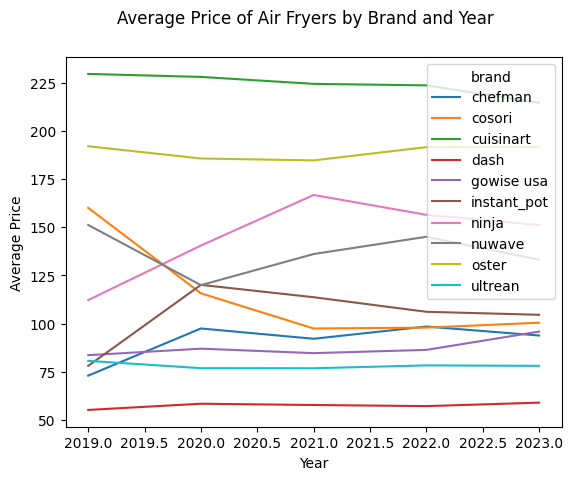

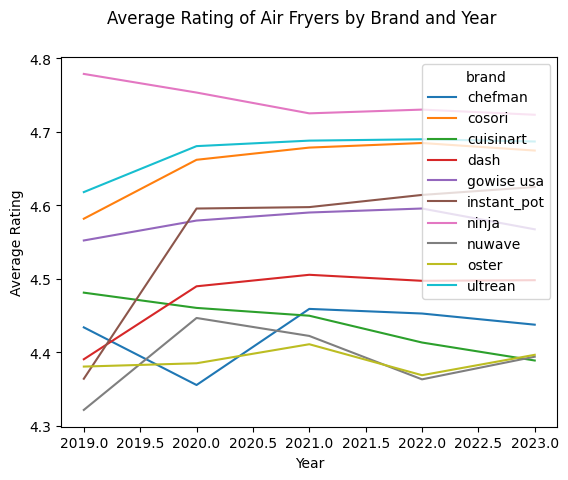

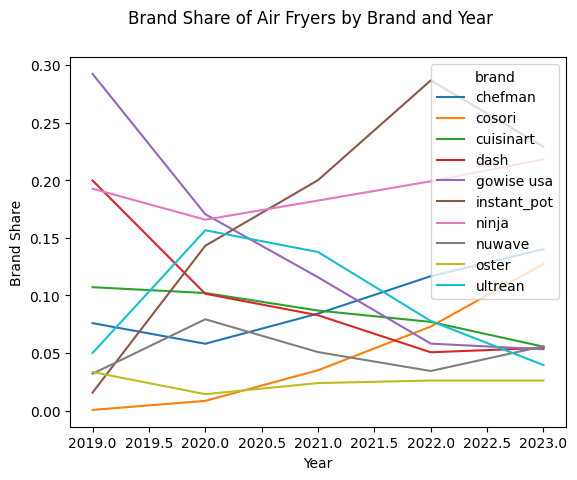

In [6]:
#2.

sns.lineplot(df, y=df["avg_price"], x=df["year"], hue=df["brand"])
plt.suptitle("Average Price of Air Fryers by Brand and Year")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.show()

sns.lineplot(df, y=df["avg_rating"], x=df["year"], hue=df["brand"])
plt.suptitle("Average Rating of Air Fryers by Brand and Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()

sns.lineplot(df, y=df["brand_share"], x=df["year"], hue=df["brand"])
plt.suptitle("Brand Share of Air Fryers by Brand and Year")
plt.xlabel("Year")
plt.ylabel("Brand Share")
plt.show()

Average share of each characteristic:
Compact: 0.9800809799122462
Dual Basket: 0.002260154798444102
Oven Style: 0.5626467503532497
Rotisserie: 0.07076203562179907
Window: 0.036741314876146694


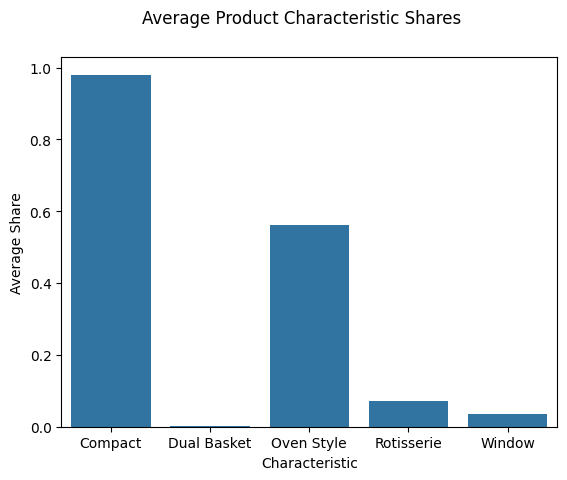

In [29]:
#3.

avg_shares = [df["compact_share"].mean(),
df["dual_basket_share"].mean(),
df["oven_style_share"].mean(),
df["rotisserie_share"].mean(),
df["window_share"].mean()]

characteristics = ["Compact", "Dual Basket", "Oven Style", "Rotisserie", "Window"]

print("Average share of each characteristic:")
for characteristic, share in zip (characteristics, avg_shares):
    print(f"{characteristic}: {share}")

sns.barplot(avg_shares)
plt.suptitle("Average Product Characteristic Shares")
plt.xticks(np.arange(5), ("Compact", "Dual Basket", "Oven Style", "Rotisserie", "Window"))
plt.xlabel("Characteristic")
plt.ylabel("Average Share")
plt.show()

The features that are most common are compact (98% of products) and oven style. However, rotesserie and widow characteristics are much more rare features, with dual-basket being extremely rare, with less than 1% of products.

In [32]:
share_columns = [col for col in df[["compact_share", "dual_basket_share", "oven_style_share", "rotisserie_share", "window_share"]]]
brand_share_means = df.groupby('brand')[share_columns].mean()
display(brand_share_means)

,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
brand,,,,,
chefman,0.961595,0.013462,0.596962,0.370490,0.363081
cosori,0.996784,0.000000,0.029952,0.024076,0.000000
cuisinart,0.995902,0.000000,0.913059,0.000000,0.000000
dash,0.999481,0.000000,0.890098,0.000000,0.000000
gowise usa,0.999877,0.000000,0.183790,0.183569,0.001320
instant_pot,0.859655,0.000030,0.674784,0.102362,0.003012
ninja,0.992084,0.002488,0.100477,0.000000,0.000000
nuwave,0.995431,0.006622,0.542646,0.027123,0.000000
oster,1.000000,0.000000,0.864518,0.000000,0.000000


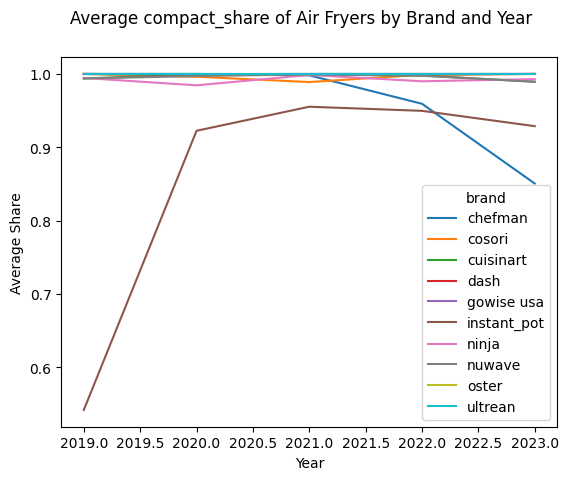

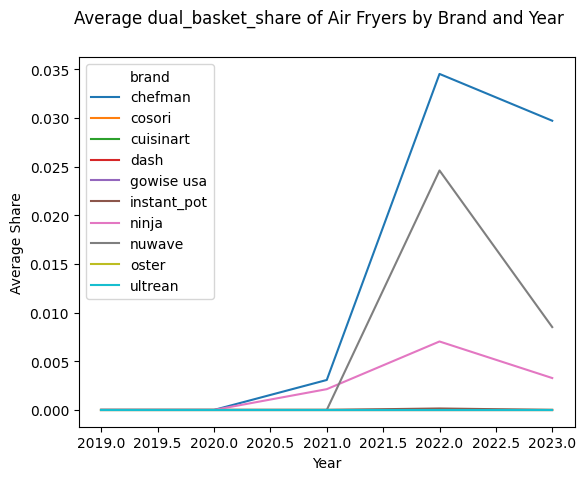

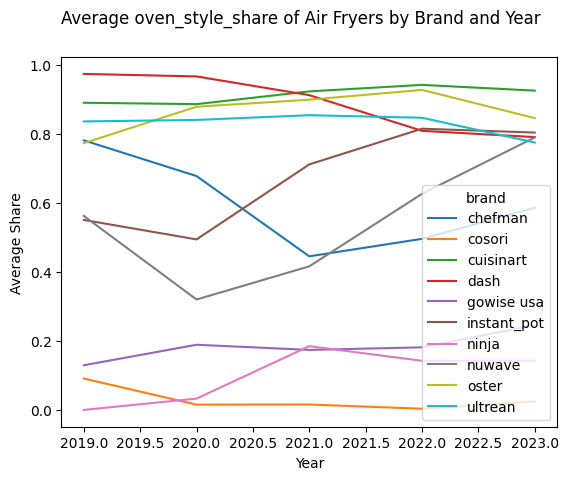

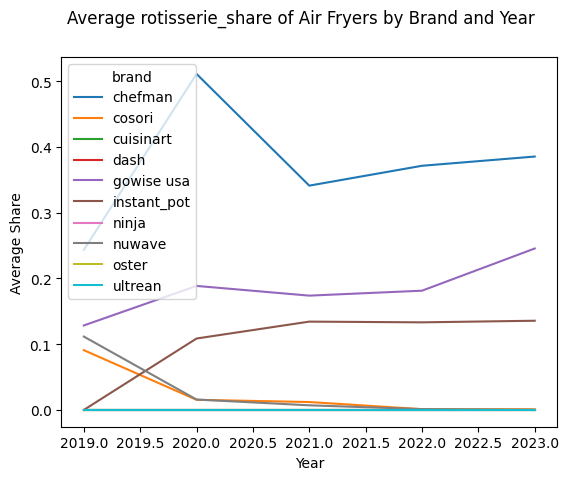

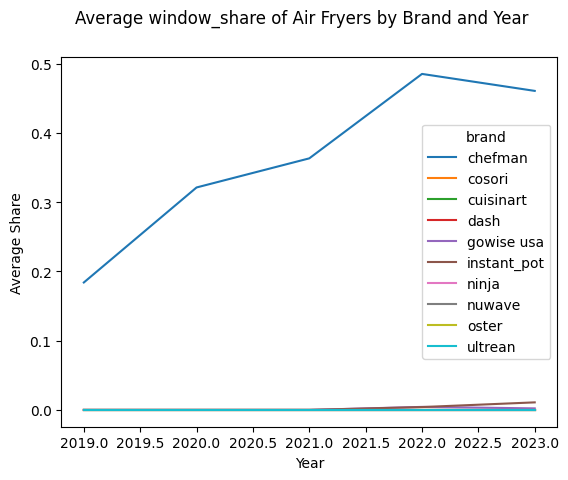

In [36]:
features = ["compact_share", "dual_basket_share", "oven_style_share", "rotisserie_share", "window_share"]

for feature in features:

  sns.lineplot(df, y=df[feature], x=df["year"], hue=df["brand"])
  plt.suptitle(f"Average {feature} of Air Fryers by Brand and Year")
  plt.xlabel("Year")
  plt.ylabel("Average Share")
  plt.show()

Almost all brands have a very high compact share, while the oven style feature is greatly distributed across the brands, with Chisinart, Dash, Oster, and Ultrean with high shares and Cosori, GoWISE USA, and Ninga with low shares. No brand seems to specialize in dual-basket air fryers with only a very small percentage in some brands including Chefman, Instant Pot, Nuwave, and Ninja. However, Chefman air fryers seem to specialize in rotisserie air fryers and widow fryers with the highest percentage in each of these categories, and average of 37 and 36%, respectfully. GoWISE USA and Instant Pot also have higher percentages in rotisserie features, showing they may be specialized, but less than Chefman, and few other brands have high shares for the window feature, indicating that Chefman specializes in this feature and rotisserie air fryers.

4.

The market, overall, of air fryers looks mostly stable. The average price of most air fryer brands has stayed largely stable, while the ratings of most brands have stayed stable as well. While these features have remained stable, the brand share of air fryers in the market has changed greatly since 2019. GoWISE USA and Dash, originally having a large market shares in 2019, no longer have as large of an impact on the market. Conversely, Instant Pot and Ninja now have much larger market shares, while both Chefman and Cosori are increasing in market shares. Ninja air fryers also consistnely have the highest ratings. It is also important to note that Chefman air fryers are more specialized in certain feature types of air fryers, including rotisserie and window features, which many other brands do not have. Cuisinart and Oster air fryers are also the most expensive. Overall, this illustrates that the market is mostly stable for air fryers, with Instant Pot and Ninja having the largest market shares.